# DTI data preparation

In this notebook, we will:
- Load diffusion MRI (DTI) data
- Understand its structure
- Visualize volumes
- Degrade the data (noise + resolution)
- Prepare it for AI-based denoising

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from functions import *

/Users/jannis/PycharmProjects/MRIProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
'Choose directory'

data_dir = "dataset/example_dti"

entries = find_dwi_datasets(data_dir)
print(f"Found {len(entries)} datasets")

Found 4 datasets


In [4]:
'Load the first dataset and print basic info'

sample = load_dwi_dataset(entries[0])

data = sample["data"]
bvals = sample["bvals"]
bvecs = sample["bvecs"]

print(f"Data shape: {data.shape}")
print(f"b-values: {bvals.shape[0]}")
print(f"b-vectors: {bvecs.shape}")

Data shape: (130, 132, 25, 130)
b-values: 130
b-vectors: (3, 130)


/Users/jannis/PycharmProjects/MRIProject/functions.py:47: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


**Data structure**

The data has shape: (X, Y, Z, N)
- X, Y, Z → spatial dimensions
- N → diffusion volumes (+ b0 images)

There are 130 b-values (N)
- Tells us how strong the diffusion gradient was for each volume
- b ≈ 0 → no diffusion weighting → “b0 image”
- b = 1000 s/mm² → diffusion-weighted image

There are 130 b-vectors
- Each b-vector tells us the direction of the diffusion gradient
- Every entry has three values, corresponding to the [gx, gy, gz] decomposition of the vector

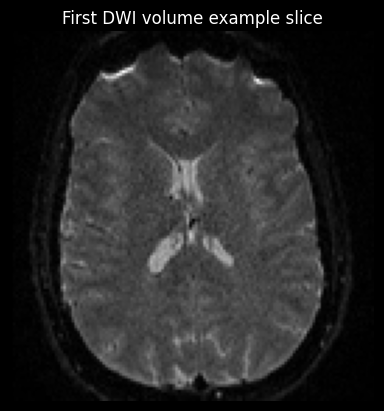

In [5]:
'Example of showing an example slice of the first DWI volume'

plt.imshow(np.rot90(data[:, :, 23, 0], 1), cmap="gray")
plt.title("First DWI volume example slice")
plt.axis("off")
plt.show()

Number of volumes: 130
b0 images: 2
dwi images: 128


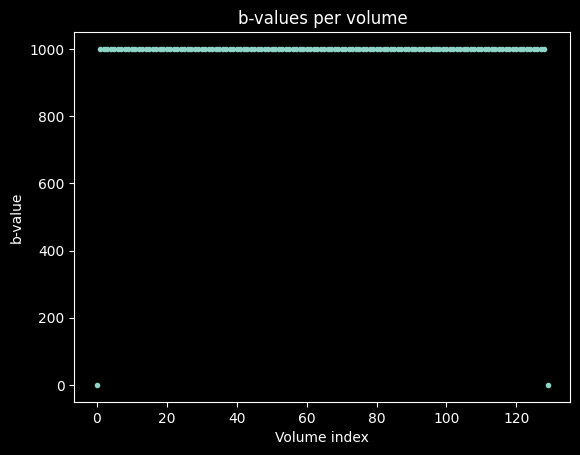

In [6]:
'Split b0 and dwi volumes'

b0, dwi = split_b0_dwi(data, bvals)
print("Number of volumes:", data.shape[-1])
print("b0 images:", b0.shape[-1])
print("dwi images:", dwi.shape[-1])

# plot b-values
plt.plot(bvals, '.')
plt.title("b-values per volume")
plt.xlabel("Volume index")
plt.ylabel("b-value")
plt.show()

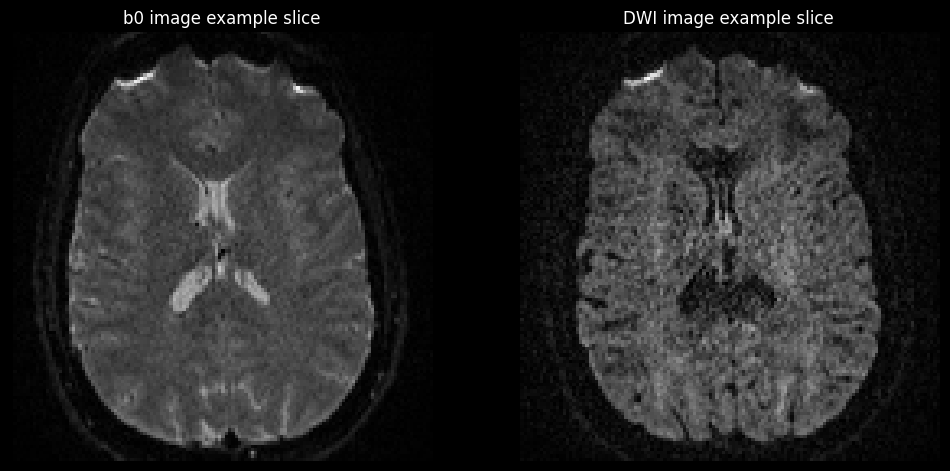

In [7]:
'Show example slices of b0 and DWI volumes'

plt.figure(figsize=(12, 9))
plt.subplot(1, 2, 1)
plt.imshow(np.rot90(b0[..., 0][:, :, 23], 1), cmap="gray")
plt.title("b0 image example slice")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(np.rot90(dwi[..., 0][:, :, 23], 1), cmap="gray")
plt.title("DWI image example slice")
plt.axis("off")
plt.show()

In [8]:
'Example of degrading the DWI data with noise and downsampling'

degraded = lowres_noise(data, noise_max=0.1, keep_fraction=0.6)

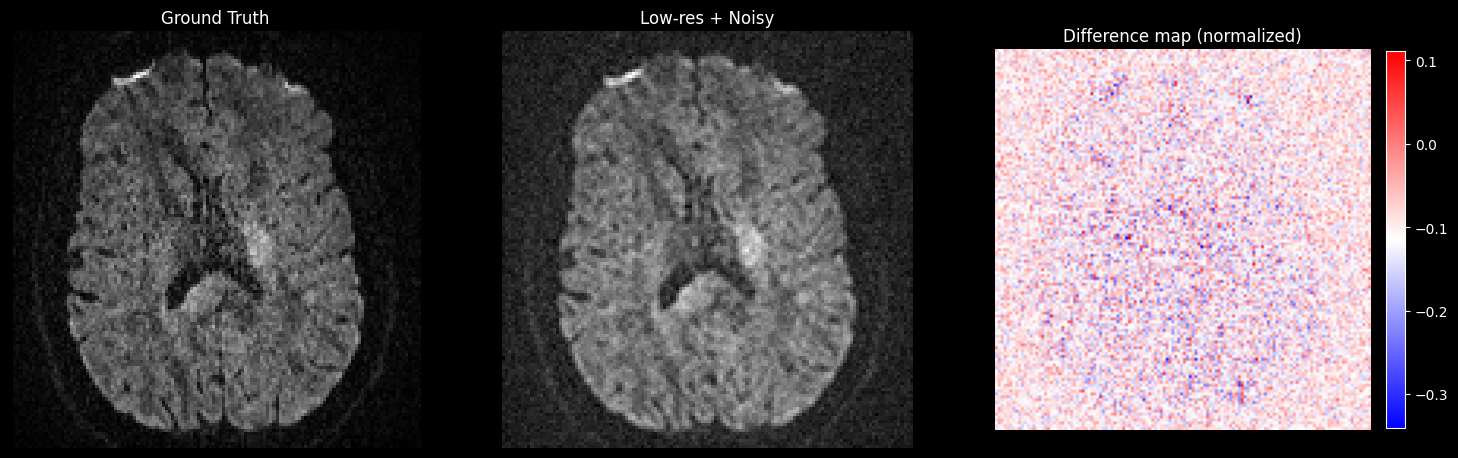

In [9]:
'Visualize example slice and timepoint from both datasets (+ difference map)'

z = 23
b = 10

gt_slice = (data[:, :, z, b] - np.min(data[:, :, z, b])) / (np.max(data[:, :, z, b]) - np.min(data[:, :, z, b]))
deg_slice = (degraded[:, :, z, b] - np.min(degraded[:, :, z, b])) / (np.max(degraded[:, :, z, b]) - np.min(degraded[:, :, z, b]))

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(np.rot90(gt_slice, 1), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.rot90(deg_slice, 1), cmap="gray")
plt.title("Low-res + Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.rot90(gt_slice - deg_slice, 1), cmap='bwr')
plt.title("Difference map (normalized)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.show()

In [10]:
'Load all datasets and prepare ML dataset with degraded inputs and clean targets'

dataset = load_all_dwi(data_dir)

print(f"Loaded {len(dataset)} subjects")

Loaded 4 subjects


In [11]:
'Prepare ML dataset with degraded inputs and clean targets'
ml_data = []

for sample in dataset:
    clean_dwi = sample["data"]
    gtab = sample["gtab"]

    degraded_dwi = lowres_noise(clean_dwi, noise_max=0.1, keep_fraction=0.6)
    
    tensor_clean = compute_dti(clean_dwi, gtab)
    tensor_clean_6d = tensor_to_6d(tensor_clean)
    
    ml_data.append({
        "input": degraded_dwi,
        "target": tensor_clean_6d,
        "bvals": sample["bvals"],
        "bvecs": sample["bvecs"]
    })

print(f"Prepared ML dataset with {len(ml_data)} samples")

Prepared ML dataset with 4 samples


In [12]:
'Save prepared dataset for ML training'

np.savez_compressed("dti_ml_dataset.npz", ml_data=ml_data)

# Extras

Here you have a few extra visualization tools to show the specific effects that noise and resolution have on the images

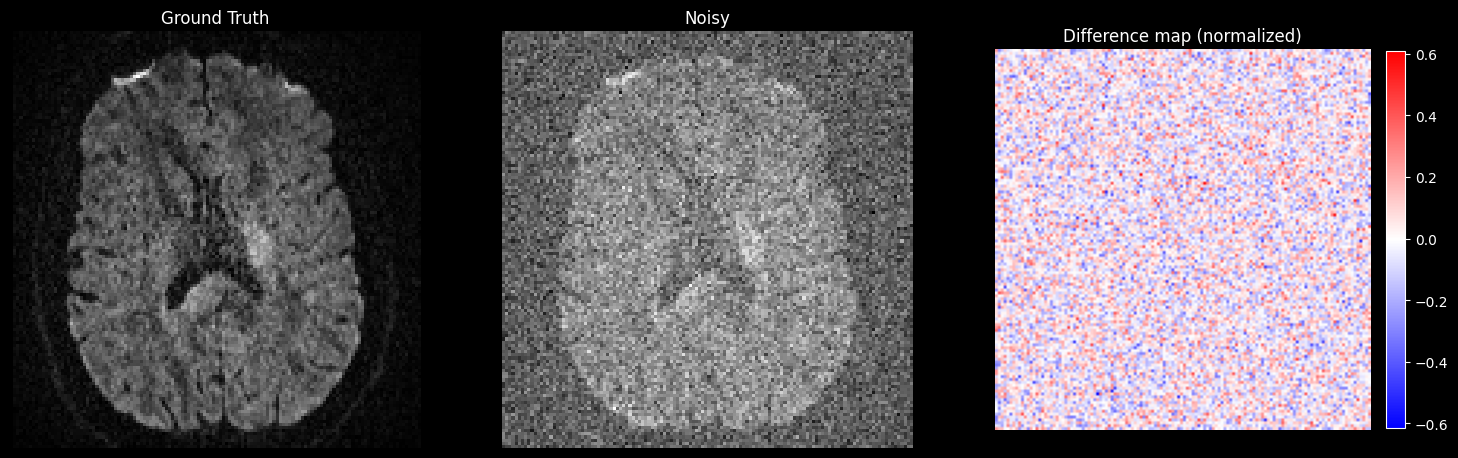

In [13]:
'Visualize noise-only differences'

z = 23
b = 10

gt_slice = data[:, :, z, b]
gt_slice = (gt_slice - np.min(gt_slice)) / (np.max(gt_slice) - np.min(gt_slice))

noise_slice = add_noise(gt_slice, 0.15)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(np.rot90(gt_slice, 1), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.rot90(noise_slice, 1), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.rot90(gt_slice - noise_slice, 1), cmap='bwr')
plt.title("Difference map (normalized)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.show()

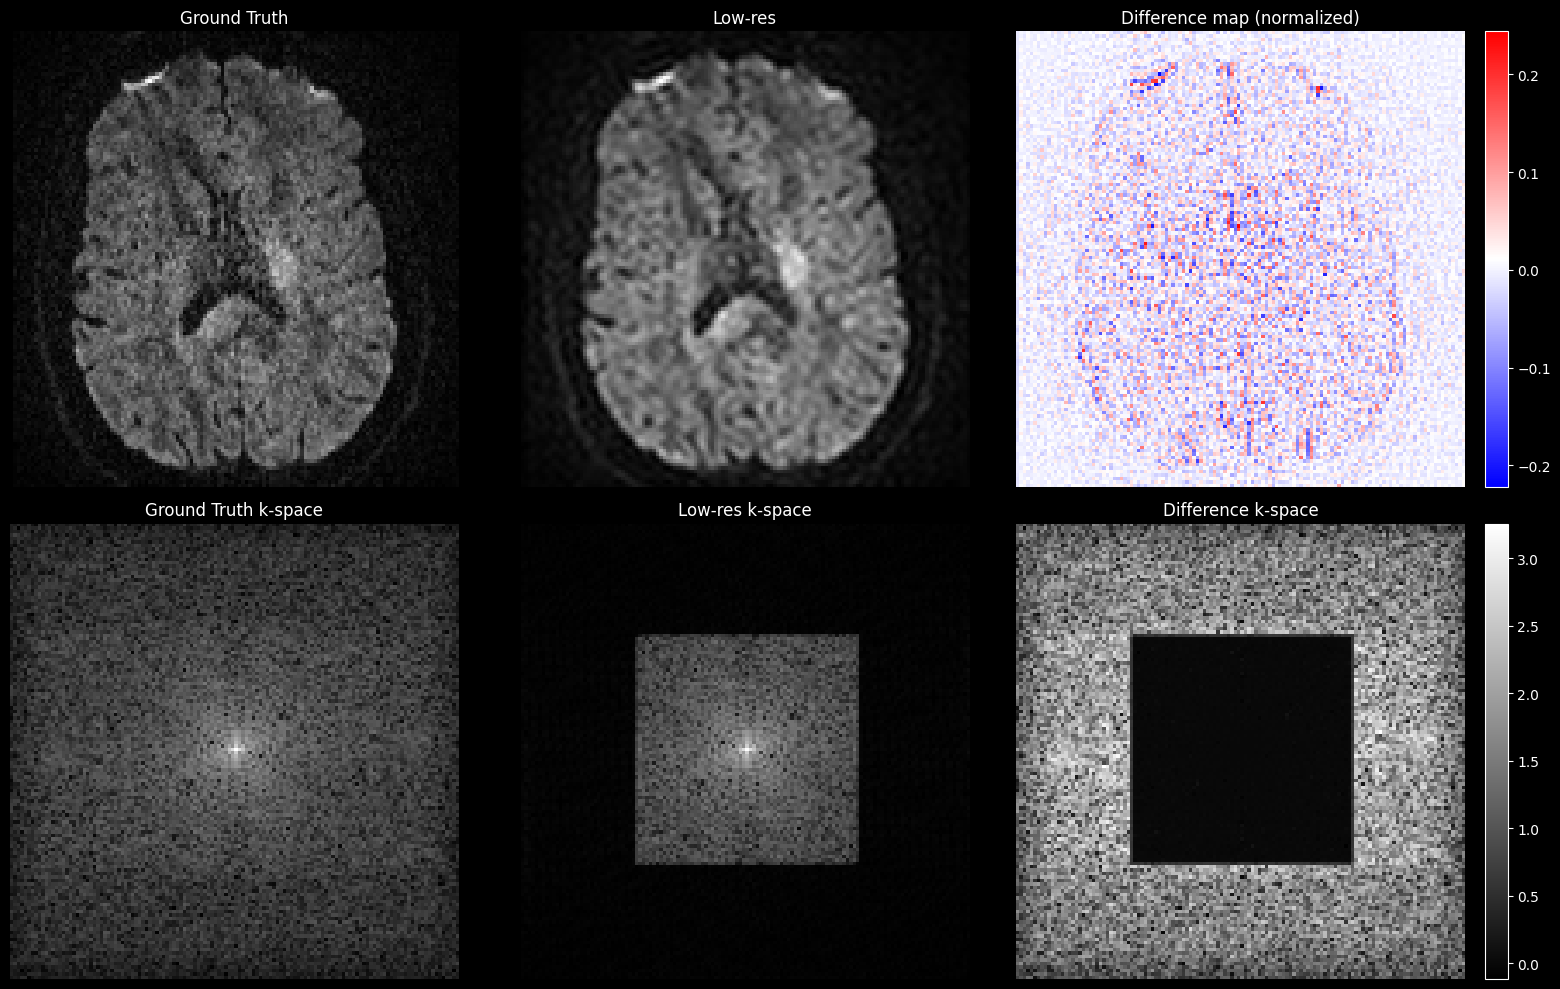

In [14]:
'Visualize resolution-only differences'

lowres_slice = apply_kspace_mask(gt_slice, keep_fraction=0.5)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(np.rot90(gt_slice, 1), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(np.rot90(lowres_slice, 1), cmap="gray")
plt.title("Low-res")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(np.rot90(gt_slice - lowres_slice, 1), cmap='bwr')
plt.title("Difference map (normalized)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 4)
plt.imshow(np.rot90(show_kspace(gt_slice), 1), cmap="gray")
plt.title("Ground Truth k-space")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(np.rot90(show_kspace(lowres_slice), 1), cmap="gray")
plt.title("Low-res k-space")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.rot90(show_kspace(gt_slice) - show_kspace(lowres_slice), 1), cmap="gray")
plt.title("Difference k-space")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

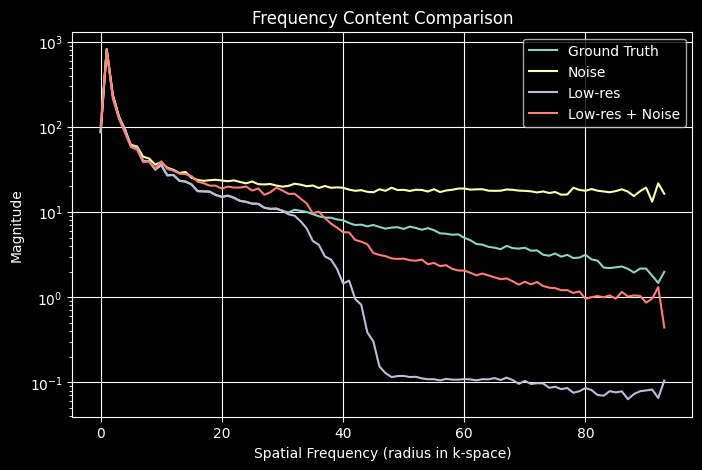

In [15]:
'Visualize changes in frequency distribution for different degradation effects'

gt_profile = radial_profile(gt_slice)
noise_profile = radial_profile(noise_slice)
lowres_profile = radial_profile(lowres_slice)
deg_slice = apply_kspace_mask(add_noise(gt_slice, noise_level=0.15), keep_fraction=0.5)
deg_profile = radial_profile(deg_slice)

plt.figure(figsize=(8,5))

plt.plot(gt_profile, label="Ground Truth")
plt.plot(noise_profile, label="Noise")
plt.plot(lowres_profile, label="Low-res")
plt.plot(deg_profile, label="Low-res + Noise")

plt.xlabel("Spatial Frequency (radius in k-space)")
plt.ylabel("Magnitude")
plt.title("Frequency Content Comparison")

plt.yscale("log")

plt.legend()
plt.grid(True)
plt.show()

Frequency effects of resolution and noise

- Ground Truth: Contains a natural balance of low and high spatial frequencies.

- Low Resolution (k-space truncation): Removes high frequencies → loss of fine details (blurring).

- Noise: Adds energy across all frequencies, especially at high frequencies → elevated baseline.

- Low Resolution + Noise: High frequencies are both reduced (by truncation) and increased (by noise), partially compensating each other and producing a spectrum that can resemble the ground truth.

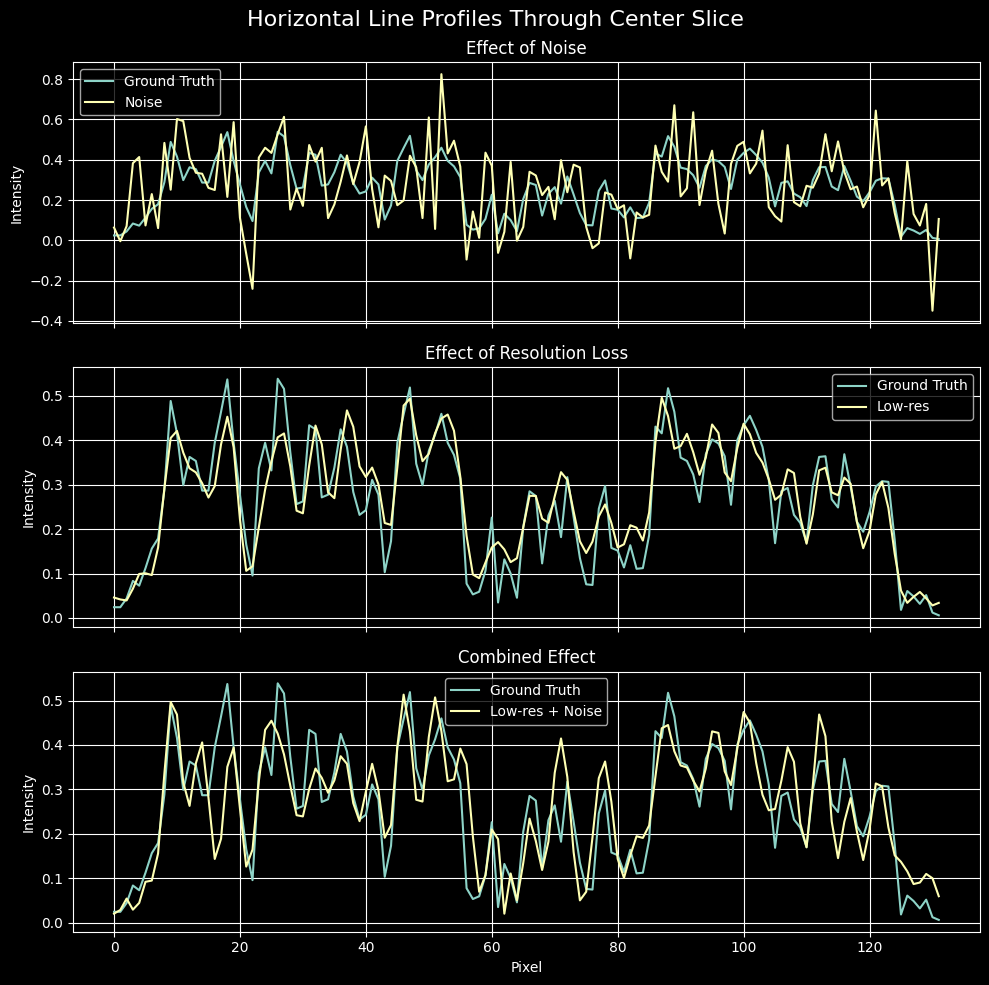

In [16]:
'Visualize profile of horizontal line through center'
y = gt_slice.shape[0] // 2

gt_line = gt_slice[y, :]
noise_line = noise_slice[y, :]
lowres_line = lowres_slice[y, :]
deg_line = deg_slice[y, :]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(gt_line, label="Ground Truth")
axes[0].plot(noise_line, label="Noise")
axes[0].set_title("Effect of Noise")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(gt_line, label="Ground Truth")
axes[1].plot(lowres_line, label="Low-res")
axes[1].set_title("Effect of Resolution Loss")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(gt_line, label="Ground Truth")
axes[2].plot(deg_line, label="Low-res + Noise")
axes[2].set_title("Combined Effect")
axes[2].legend()
axes[2].grid(True)

axes[2].set_xlabel("Pixel")
for ax in axes:
    ax.set_ylabel("Intensity")

fig.suptitle("Horizontal Line Profiles Through Center Slice", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
'Generate DTI metrics for clean and degraded data'

sample = ml_data[0]

tensor6 = sample["target"]

mask, _ = brain_mask(np.mean(dwi, axis=-1))

fa = compute_fa_from_tensor6(tensor6) * mask
md = compute_md_from_tensor6(tensor6) * mask
color_fa = compute_color_fa_from_tensor6(tensor6) * mask[..., None]

example = dataset[0]
dwi = example["data"]
example_gtab = example["gtab"]
degraded_example = lowres_noise(dwi, noise_max=0.15, keep_fraction=0.6)
tensor6_degraded = tensor_to_6d(compute_dti(degraded_example, example_gtab))

fa_degraded = compute_fa_from_tensor6(tensor6_degraded) * mask
md_degraded = compute_md_from_tensor6(tensor6_degraded) * mask
color_fa_degraded = compute_color_fa_from_tensor6(tensor6_degraded) * mask[..., None]

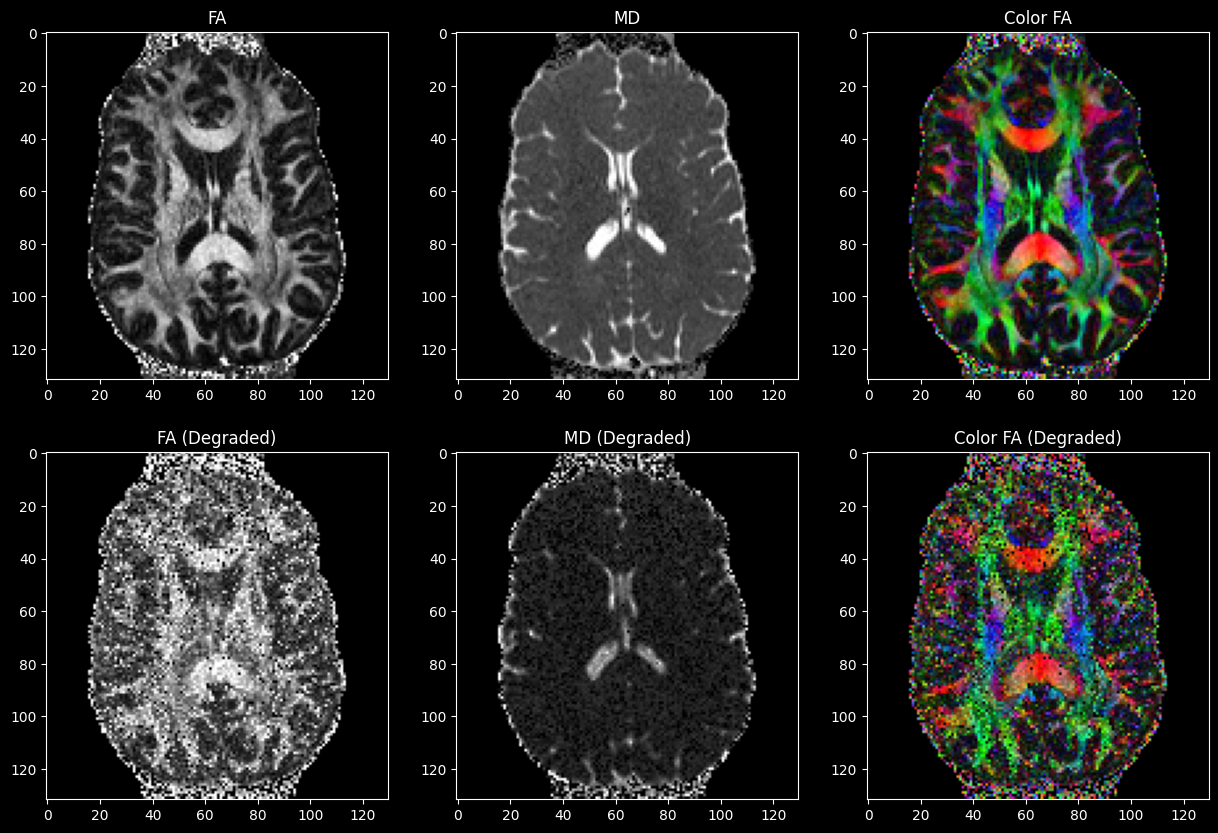

In [18]:
'Visualize DTI metrics for clean and degraded data'

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0,0].imshow(norm(np.rot90(fa[:, :, 23], 1)), cmap="gray")
axes[0,0].set_title("FA")
axes[0,1].imshow(norm(np.rot90(md[:, :, 23], 1)), cmap="gray")
axes[0,1].set_title("MD")
axes[0,2].imshow(norm(np.rot90(color_fa[:, :, 23], 1)), cmap="gray")
axes[0,2].set_title("Color FA")
axes[1,0].imshow(norm(np.rot90(fa_degraded[:, :, 23], 1)), cmap="gray")
axes[1,0].set_title("FA (Degraded)")
axes[1,1].imshow(norm(np.rot90(md_degraded[:, :, 23], 1)), cmap="gray")
axes[1,1].set_title("MD (Degraded)")
axes[1,2].imshow(norm(np.rot90(color_fa_degraded[:, :, 23], 1)), cmap="gray")
axes[1,2].set_title("Color FA (Degraded)")
plt.show()
